#### Use inset_axes() to pin multiple histograms on a map.
- Use Cartopy to plot the map.
- Define locations (latitude, longitude) to pin the histograms.
- Create individual histograms at each location.
- median and percentile ranges for projected percentage changes in TC frequency, category >=2 TC frequency
    - For TC frequency, the 5th–95th-percentile range across published estimates is shown.
    - For category >=2, TC frequency, TC intensity, and TC near-storm rain rates the 10th–90th-percentile range is shown.
    - To manually set fliers outside the interquartile range [q1,q3] in a custom boxplot 
- Overlay the histograms on the map using - ax.inset_axes() or OffsetImage from mpl_toolkits.axes_grid1

Ming Ge July 2025
 

In [12]:
import numpy as np
import glob
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Rectangle
from matplotlib.colors import BoundaryNorm, ListedColormap

import cartopy.crs as ccrs
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import tc_helping
from importlib import reload
reload(tc_helping)
from  tc_helping import ts_trend, ts_trendline, \
                        ts_trendline_en, \
                        rd_IB_OX,         \
                        rd_IB_OX_landfall, \
                        rd_E5_Traj_SH,      \
                        rd_E5_Traj_SH_OZlandfall, \
                        rd_HR_SH_new, \
                        rd_HR_landfall_SH

import warnings
warnings.filterwarnings("ignore")

#### Global variables are defined here

In [2]:
#### some global variables used in this notebook
dir_hr   = '/glade/campaign/mmm/c3we/done/pcast/CESM_HR/'
dir_prec = '/glade/campaign/mmm/c3we/mingge/CESM-HR/'
 

# 5 Buckley Cyclone Regions and New Zealand
region_s = ['BC 1', 'BC 2', 'BC 3', 'BC 4', 'BC 5', 'New Zealand']
color_s = ['lavender', 'mistyrose', 'wheat', 'lightyellow', 'bisque','oldlace']

lat_s_1d = [-40, -27, -20, -25, -40, -48]
lat_e_1d = [-27, -9,  -9,  -9,  -22, -30]
# Use the latitude of 25S as the boundary between the regions on the West side and the East side of Australia.
lat_e_1d = [-25, -9,  -9,  -9,  -25, -30]
lon_s_1d = [145, 143, 132, 100, 100, 163]
lon_e_1d = [160, 158, 143, 132, 145, 183] 

n_region = len(lat_s_1d)

n_mem = 10

kt2ms = 0.514444 
SAFFIR_SIM_CAT = [34, 64, 83, 96, 113, 137, 1000]
# because Australia use 10-min avg MSW (kts)
# Saffir/Simpson Scale is for 1-min
# Australian Scale in terms of Saffir/Simpson Scale 1-min
# https://australiasevereweather.com/cyclones/tropical_cyclone_intensity_scale.htm
Australian_CAT_1min  = [38, 55, 65, 86, 107, 1000]
Australian_CAT_10min = [34, 48, 74, 97, 120, 1000]

In [3]:
def create_box(data1, q1, q3):
    '''

    '''
    # Compute custom statistics for data1 (with whiskers equal to Q1 and Q3)
    q1_1 = np.percentile(data1, q1)
    q3_1 = np.percentile(data1, q3)

    # To manually set fliers (outliers) outside the interquartile range [q1, q3]
    fliers_1 = data1[(data1 < q1_1) | (data1 > q3_1)]
    
    box = {
        'med': np.median(data1),
        'q1': q1_1,
        'q3': q3_1,
        'whislo': q1_1,  # lower whisker set to Q1
        'whishi': q3_1,  # upper whisker set to Q3
        'fliers': fliers_1 # [] no outliers
    }

    return box

In [4]:
# plot 6 3-set of 2-box custom boxplots in a single figure 
def box_custom_inset_2p(ax, data1, data2, q1, q3, title_s, x_title, y_label, is_commonY, is_dot_ib=False, is_dot_e5=False):
    '''
    q1: two Q1 correspondent to data1, data2
    q3: two Q3 correspondent to data1, data2
    is_dot_ib: add IB track trend as a dot
            = False or [trend1, trend2] a list of 2 numbers
    is_dot_e5: add ERA5 track trend as a dot
            = False or [trend1, trend2] a list of 2 numbers
    '''
    
    box1 = create_box(data1, q1[0], q3[0])
    box2 = create_box(data2, q1[1], q3[1])
     
    flier_style = dict(marker='o', 
                       markerfacecolor='blue', 
                       markersize=2, 
                       linestyle='none')
    
    #  Use patch_artist=True so that boxes are drawn as Patch objects
    ax.bxp([box1, box2], widths=0.55, patch_artist=True,
           flierprops=flier_style,
           boxprops={'facecolor': 'grey', 'alpha':0.5}, 
                    #'color': 'lightsteelblue'},
                   #whiskerprops={'color': 'grey'},
                   #capprops={'color': 'grey'},
                   medianprops={'color': 'black'})

    # Add a scatter dot for each box y  
    if not is_dot_ib is False:
        for ii, box in enumerate([box1, box2]):
            xx = ii + 1  # box positions start at 1
            yy = is_dot_ib[ii]    # value of dot (will use IBTracs)
            ax.scatter(xx, yy, color='green', s=20, alpha=0.5, zorder=3, label='Dot' if ii == 0 else "")  # label only first for legend
    if not is_dot_e5 is False:
        for ii, box in enumerate([box1, box2]):
            xx = ii + 1  # box positions start at 1
            yy = is_dot_e5[ii]    # value of dot (will use ERA5 tracke)
            ax.scatter(xx, yy, color='red', s=20, alpha=0.5, zorder=3, label='Dot' if ii == 0 else "")  
   
    # Add a horizontal line at y=0
    # ax.axhline(y=0, color='grey', linestyle='--', linewidth=1)

    # Set the font size of the y-axis tick labels
    ax.tick_params(axis='y', labelsize=6, pad=0)  # Adjust 'labelsize' as needed
    
    if is_commonY: 
        ax.set_ylim(-25, 50)
        
    ax.set_xticklabels(x_title, fontsize=5)
     
    ax.set_title(title_s, fontsize=6)
    ax.set_ylabel(y_label, labelpad=0, fontsize=8)

def call_box_custom_inset_3p(slope_4d, is_commonY = False, title_s='', slope_ib=False, slope_e5=False):
    '''
    is_commonY: the same Y-axis ticks
    n_region, lat_s_1d,  lon_s_1d, read from global variable
    slope_ib: False
           True  IB trend as a dot
    slope_e5: False
           True ERA5 trend as a dot
    '''
    n_cat = slope_4d.shape[3]
    n_var = slope_4d.shape[0]
    
    # Map locations (latitude, longitude)
    latc_1d = ((np.array(lat_s_1d) + np.array(lat_e_1d))/2).tolist()
    lonc_1d = ((np.array(lon_s_1d) + np.array(lon_e_1d)-14)/2).tolist()

    # location of 1st histogram 
    locations_1 = list(zip(latc_1d, lonc_1d))

    # location of 2nd histogram 
    lonc_1d = ((np.array(lon_s_1d) + np.array(lon_e_1d)-3)/2).tolist()
    locations_2 = list(zip(latc_1d, lonc_1d))

    # location of 3rd histogram 
    lonc_1d = ((np.array(lon_s_1d) + np.array(lon_e_1d)+8)/2).tolist()
    locations_3 = list(zip(latc_1d, lonc_1d))

    locations = [locations_1, locations_2, locations_3]
    x_title = [['TC', 'Cat 2-5 Fre'], ['TC', 'Cat 2-5 Inten'], ['TC', 'Cat 2-5 Prec']]

    # Plot the map
    fig, ax = plt.subplots(figsize=(12, 8), dpi=300, 
                           subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([100, 180, -50, -5], crs=ccrs.PlateCarree())

    # Add map features
    #ax.stock_img()
    ax.coastlines()
    #ax.gridlines(draw_labels=True)

    # Plot histograms at different locations
    for nr in range(n_region):   
        data_1 = slope_4d[0, nr, :, 0]
        data_2 = slope_4d[0, nr, :, 1]
        data_3 = slope_4d[1, nr, :, 0]
        data_4 = slope_4d[1, nr, :, 1]
        data_5 = slope_4d[2, nr, :, 0]
        data_6 = slope_4d[2, nr, :, 1]

        # Add rectangle for bounding box
        bbox = Rectangle((lon_s_1d[nr], lat_s_1d[nr]), lon_e_1d[nr] - lon_s_1d[nr], lat_e_1d[nr] - lat_s_1d[nr],
                 edgecolor=color_s[nr], facecolor=color_s[nr], linewidth=1,
                 transform=ccrs.PlateCarree())
        ax.add_patch(bbox)

        for nn in range(n_var):
            if nn==0:
                y_label = 'mean'
            else:
                y_label = ''
                
            lat, lon = locations[nn][nr]

            if nr == 1:
                lon = lon + 6
                
            # Create an inset axes for each histogram
            inset_ax = inset_axes(ax, width=0.5, height=1.0, 
                          loc='center',
                          # Use absolute positioning
                          bbox_to_anchor=(lon, lat, 0, 0),
                          bbox_transform=ax.transData, borderpad=0)
    
            # Set axes background to some transparent
            inset_ax.patch.set_alpha(0.7)

            if (slope_ib is False) or nn == 2:
                box_custom_inset_2p(inset_ax, slope_4d[nn,nr,:,0], slope_4d[nn,nr,:,1],
                            [5,10], [95,90], region_s[nr], x_title[nn], y_label, 
                                        is_commonY, is_dot_ib=False)
            else:
                if slope_e5 is False:
                    box_custom_inset_2p(inset_ax, slope_4d[nn,nr,:,0], slope_4d[nn,nr,:,1], 
                                        [5,10], [95,90], region_s[nr], x_title[nn], y_label, 
                                        is_commonY, slope_ib[nn,nr,:].tolist())
                else:
                    box_custom_inset_2p(inset_ax, slope_4d[nn,nr,:,0], slope_4d[nn,nr,:,1],
                                        [5,10], [95,90], region_s[nr], x_title[nn], y_label, 
                                        is_commonY, slope_ib[nn,nr,:].tolist(), slope_e5[nn,nr,:].tolist())
 
    ax.set_title(title_s, fontsize=14, fontweight='bold') 

In [5]:
# plot 6 2-set of custom boxplots in a single figure 
 
def call_box_custom_inset_2p(slope_4d, is_commonY = False, title_s='', slope_ib=False, slope_e5=False):
    '''
    is_commonY: the same Y-axis ticks
    n_region, lat_s_1d,  lon_s_1d, read from global variable
    slope_ib: False
           True  IB trend as a green dot
    slope_e5: False
           True ERA5 trend as a red dot
    '''
     
    n_cat = slope_4d.shape[3]
    n_var = slope_4d.shape[0]
    n_var = 2
    
    # Map locations (latitude, longitude)
    latc_1d = ((np.array(lat_s_1d) + np.array(lat_e_1d))/2).tolist()
    lonc_1d = ((np.array(lon_s_1d) + np.array(lon_e_1d)-7)/2).tolist()

    # location of 1st histogram
    locations_1 = list(zip(latc_1d, lonc_1d))

    # location of 2nd histogram
    lonc_1d = ((np.array(lon_s_1d) + np.array(lon_e_1d)+7)/2).tolist()
    locations_2 = list(zip(latc_1d, lonc_1d))

    locations = [locations_1, locations_2]
    x_title = [['TC', 'Cat 2-5 Fre'], ['TC', 'Cat 2-5 Inten']]

    # Plot the map
    fig, ax = plt.subplots(figsize=(12, 8), dpi=300, 
                           subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_extent([100, 180, -50, -5], crs=ccrs.PlateCarree())

    # Add map features
    #ax.stock_img()
    ax.coastlines()
    #ax.gridlines(draw_labels=True)

    # Plot histograms at different locations
    for nr in range(n_region):   
        data_1 = slope_4d[0, nr, :, 0]
        data_2 = slope_4d[0, nr, :, 1]
        data_3 = slope_4d[1, nr, :, 0]
        data_4 = slope_4d[1, nr, :, 1]

        # Add rectangle for bounding box
        bbox = Rectangle((lon_s_1d[nr], lat_s_1d[nr]), lon_e_1d[nr] - lon_s_1d[nr], lat_e_1d[nr] - lat_s_1d[nr],
                 edgecolor=color_s[nr], facecolor=color_s[nr], linewidth=1,
                 transform=ccrs.PlateCarree())
        ax.add_patch(bbox)

        for nn in range(n_var):
            if nn==0:
                y_label = 'mean'
            else:
                y_label = ''
                
            lat, lon = locations[nn][nr]
            
            # Create an inset axes for each histogram
            inset_ax = inset_axes(ax, width=0.5, height=1.0, 
                          loc='center',
                          # Use absolute positioning
                          bbox_to_anchor=(lon, lat, 0, 0),
                          bbox_transform=ax.transData, borderpad=0)
    
            # Set axes background to some transparent
            inset_ax.patch.set_alpha(0.7)

            if slope_ib is False:
                box_custom_inset_2p(inset_ax, slope_4d[nn, nr, :, 0], slope_4d[nn, nr, :, 1], 
                            [5,10], [95,90], region_s[nr], x_title[nn], y_label, is_commonY, is_dot_ib=False)
            else:
                if slope_e5 is False:
                    box_custom_inset_2p(inset_ax, slope_4d[nn, nr, :, 0], slope_4d[nn, nr, :, 1], 
                                        [5,10], [95,90], region_s[nr], x_title[nn], y_label, 
                                        is_commonY, slope_ib[nn,nr,:].tolist())
                else:
                    box_custom_inset_2p(inset_ax, slope_4d[nn, nr, :, 0], slope_4d[nn, nr, :, 1], 
                                        [5,10], [95,90], region_s[nr], x_title[nn], y_label, 
                                        is_commonY, slope_ib[nn,nr,:].tolist(), slope_e5[nn,nr,:].tolist())
                    #print('slope_ib')
                    #print(slope_ib[nn,nr,:].tolist())
                    #print('slope_e5')
                    #print(slope_e5[nn,nr,:].tolist())
 
    ax.set_title(title_s, fontsize=14, fontweight='bold') 

In [6]:
# read CESH-HR TC track data
def rd_HR_SH_prec(dir_prec, year_s, year_e, extent, spd_1d):
    '''
    SH hurrican year is from previous Dec to next April
    return data_4d[n_mem, n_year, n_var, n_cat]
    n_year: year_e - year_s + 1
    n_var: 0: TC count, 1: wind intensity, 2: prec  
    n_cat: 0: all TCs, 1: >= Cat 2
    return data_4d(n_mem, n_year, n_var, n_cat)
    '''
    lon_s = extent[0]
    lon_e = extent[1]
    lat_s = extent[2]
    lat_e = extent[3]
          
    n_year = year_e - year_s + 1
          
    dirs = [ff for ff in glob.glob(dir_prec + "CESM_HR_E??_TCs")]
    n_mem = len(dirs)
     
    # 0: tc count, 1: intensity, 2:prec
    n_var = 3
    # 0: >=spd_1d[0], 1: >= spd_1d[1]
    n_cat = 2

    data_4d  = np.zeros((n_mem, n_year, n_var, n_cat))
    data_4d[:] = np.nan
    # initial TC count = 0
    data_4d[:,:,0,:] = 0

    nm = 0

    for dir in dirs:
        # The TC season in the SH runs from 
        # December 1st of the previous year to April 30th of the current year.
        for year in range(year_s, year_e + 1):
            name = dir[len(dir_prec) + 8:-4]
             
            flnm_p = dir + '/' + 'CESM_HR_TC_'+ name+'_output_' + str(year-1) + '_SH.txt'
            flnm = dir + '/' + 'CESM_HR_TC_'+ name+'_output_' + str(year) + '_SH.txt'

            # CESM-HR dataset is from 1920 to 2100
            if year != 1920:
                df_p = pd.read_csv(flnm_p, delimiter=',', engine='python')
            df_tc = pd.read_csv(flnm, delimiter=',', engine='python')

            vmax_annual = 0
            prec_annual = 0

            if year == 1920:
                df = df_tc.loc[df_tc['year'].astype(int) == year &
                             ((df_tc['month'].astype(int) >= 1) &
                              (df_tc['month'].astype(int) <= 4))]
            else:
                df_0 = df_p.loc[(df_p['year'].astype(int) == year-1) &
                                (df_p['month'].astype(int) == 12)]
                df_c = df_tc.loc[(df_tc['year'].astype(int) == year) &
                                 (df_tc['month'].astype(int) >= 1) &
                                 (df_tc['month'].astype(int) <= 4)]
                df = pd.concat([df_0, df_c], ignore_index=True)

            tc_ids = np.unique(df.track_id.astype(int))
            for tc_id in tc_ids:
                df_subset = df.loc[df.track_id.astype(int) == tc_id]

                # Combine all conditions
                # if any row satisfies all four conditions at once.
                condition1 = (
                    (df_subset['lat'] >= lat_s) & (df_subset['lat'] <= lat_e) &
                    (df_subset['lon'] >= lon_s) & (df_subset['lon'] <= lon_e) &
                    (df_subset['wind10'] >= spd_1d[0]*kt2ms)
                    )
                condition2 = (
                    (df_subset['lat'] >= lat_s) & (df_subset['lat'] <= lat_e) &
                    (df_subset['lon'] >= lon_s) & (df_subset['lon'] <= lon_e) &
                    (df_subset['wind10'] >= spd_1d[1]*kt2ms)
                    )

                # Check if any row meets the combined condition
                any_match1 = condition1.any()
                any_match2 = condition2.any()
                
                if any_match1:
                    vmax_annual = max(np.max(df_subset[condition1]['wind10'].max()), vmax_annual)
                    prec_annual = max(np.max(df_subset[condition1]['prec'].max()), prec_annual)
                    data_4d[nm, year-year_s, 0, 0] += 1
                    data_4d[nm, year-year_s, 1, 0] = vmax_annual
                    data_4d[nm, year-year_s, 2, 0] = prec_annual
                if any_match2:
                    vmax_annual = max(np.max(df_subset[condition2]['wind10'].max()), vmax_annual)
                    prec_annual = max(np.max(df_subset[condition2]['prec'].max()), prec_annual)
                    data_4d[nm, year-year_s, 0, 1] += 1
                    data_4d[nm, year-year_s, 1, 1] = vmax_annual
                    data_4d[nm, year-year_s, 2, 1] = prec_annual

        nm = nm + 1

    return data_4d

#### 1980-2018
Using ERA5 track period

In [23]:
year_s = 1980
year_e = 2018

year_s = 2020
year_e = 2100

year_1d = np.array(range(year_s, year_e+1))

# 0: tc frequency, 1:intensity, 3: Prec
n_var = 3

# 0: >= Cat 1,  1: >= Cat 2
n_cat = 2

landfall = True  #True or False

slope_ib = np.zeros((n_var-1, n_region, n_cat))
slope_e5 = np.zeros((n_var-1, n_region, n_cat))
slope_ie = np.zeros((n_var-1, n_cat))

# Only 9 members has 6-hourly preci. 
if landfall == True:
    n_mem = 9
    slope_4d = np.zeros((n_var, n_region, n_mem, n_cat))
else:
    n_mem = 10
    slope_4d = np.zeros((n_var-1, n_region, n_mem, n_cat))

for nr in range(n_region):
    if nr == n_region - 1:
        country_s = 'New Zealand'
        print(country_s)
    else:
        country_s = 'Australia'
        print(country_s  + ' Buckley Cyclone Region ' + str(nr + 1))
        
    lat_s = lat_s_1d[nr]
    lat_e = lat_e_1d[nr]
    lon_s = lon_s_1d[nr]
    lon_e = lon_e_1d[nr]
    lon_cen = (lon_s+lon_e)*0.5
        
    extent = [lon_s, lon_e, lat_s, lat_e]

    if year_e < 2020:
      for obs in range(2):
        # for IBTrACS: 
        if obs == 0:
            # Calculate IBTrACS slope
            if landfall == True:
                df_BC_0 = rd_IB_OX_landfall(year_s, year_e, extent, Australian_CAT_10min[0])    
                df_BC_1 = rd_IB_OX_landfall(year_s, year_e, extent, Australian_CAT_10min[1])
            else:
                df_BC_0 = rd_IB_OX(year_s, year_e, extent, Australian_CAT_10min[0])    
                df_BC_1 = rd_IB_OX(year_s, year_e, extent, Australian_CAT_10min[1])
        # for ERA5
        else:
            if landfall == True:
                df_BC_0 = rd_E5_Traj_SH_OZlandfall(country_s, year_s, year_e, extent, 0)    
                df_BC_1 = rd_E5_Traj_SH_OZlandfall(country_s, year_s, year_e, extent, 0.652*Australian_CAT_10min[1]*kt2ms)
            else:
                df_BC_0 = rd_E5_Traj_SH(year_s, year_e, extent, 0)    
                df_BC_1 = rd_E5_Traj_SH(year_s, year_e, extent, 0.652*Australian_CAT_10min[1]*kt2ms)
             
        # try mean instead of trend
        slope_ie[0,0] = df_BC_0['TC Count'].mean()
        slope_ie[0,1] = df_BC_1['TC Count'].mean()

        slope_ie[1,0] = df_BC_0['Vmax'].mean()
        slope_ie[1,1] = df_BC_1['Vmax'].mean() 

        # for IBTrACS: 
        if obs == 0:
            slope_ib[:,nr] = slope_ie
        else:
            slope_e5[0, nr] = slope_ie[0]
            slope_e5[1, nr] = slope_ie[1]/kt2ms

    # CESM-HR
    if landfall == True:
        # rd_HR_SH_prec is for 7-deg landfall with preci
        data_HR_BCR1 = rd_HR_SH_prec(dir_prec, year_s, year_e, extent, Australian_CAT_10min[:2])
        data_prec = data_HR_BCR1[:,:,2,:] 
        n_var_new = n_var
    else:
        n_var_new = n_var - 1
        data_HR_BCR1 = rd_HR_SH_new(dir_hr, year_s, year_e, extent, Australian_CAT_10min[:2])
        
    # TC frequency (n_mem, n_year, [>=cat1, cat2-5])
    data_fre = data_HR_BCR1[:,:,0,:]  
    data_spd = data_HR_BCR1[:,:,1,:]/kt2ms 
     
    for nm in range(n_mem):
        for nc in range(n_cat):
            #slope_4d[0, nr, nm, nc] = np.polyfit(year_1d, data_fre[nm,:,nc], 1)[0]
            slope_4d[0, nr, nm, nc] = np.nanmean(data_fre[nm,:,nc])
            slope_4d[1, nr, nm, nc] = np.nanmean(data_spd[nm,:,nc])
              
            if landfall == True:
                slope_4d[2, nr, nm, nc] = np.nanmean(data_prec[nm,:,nc])

if year_s == 1980:
    slope_4d_h = slope_4d
    slope_ib_h = slope_ib
    slope_e5_h = slope_e5
if year_s == 2020:
    slope_4d_f = slope_4d

Australia Buckley Cyclone Region 1
Australia Buckley Cyclone Region 2
Australia Buckley Cyclone Region 3
Australia Buckley Cyclone Region 4
Australia Buckley Cyclone Region 5
New Zealand


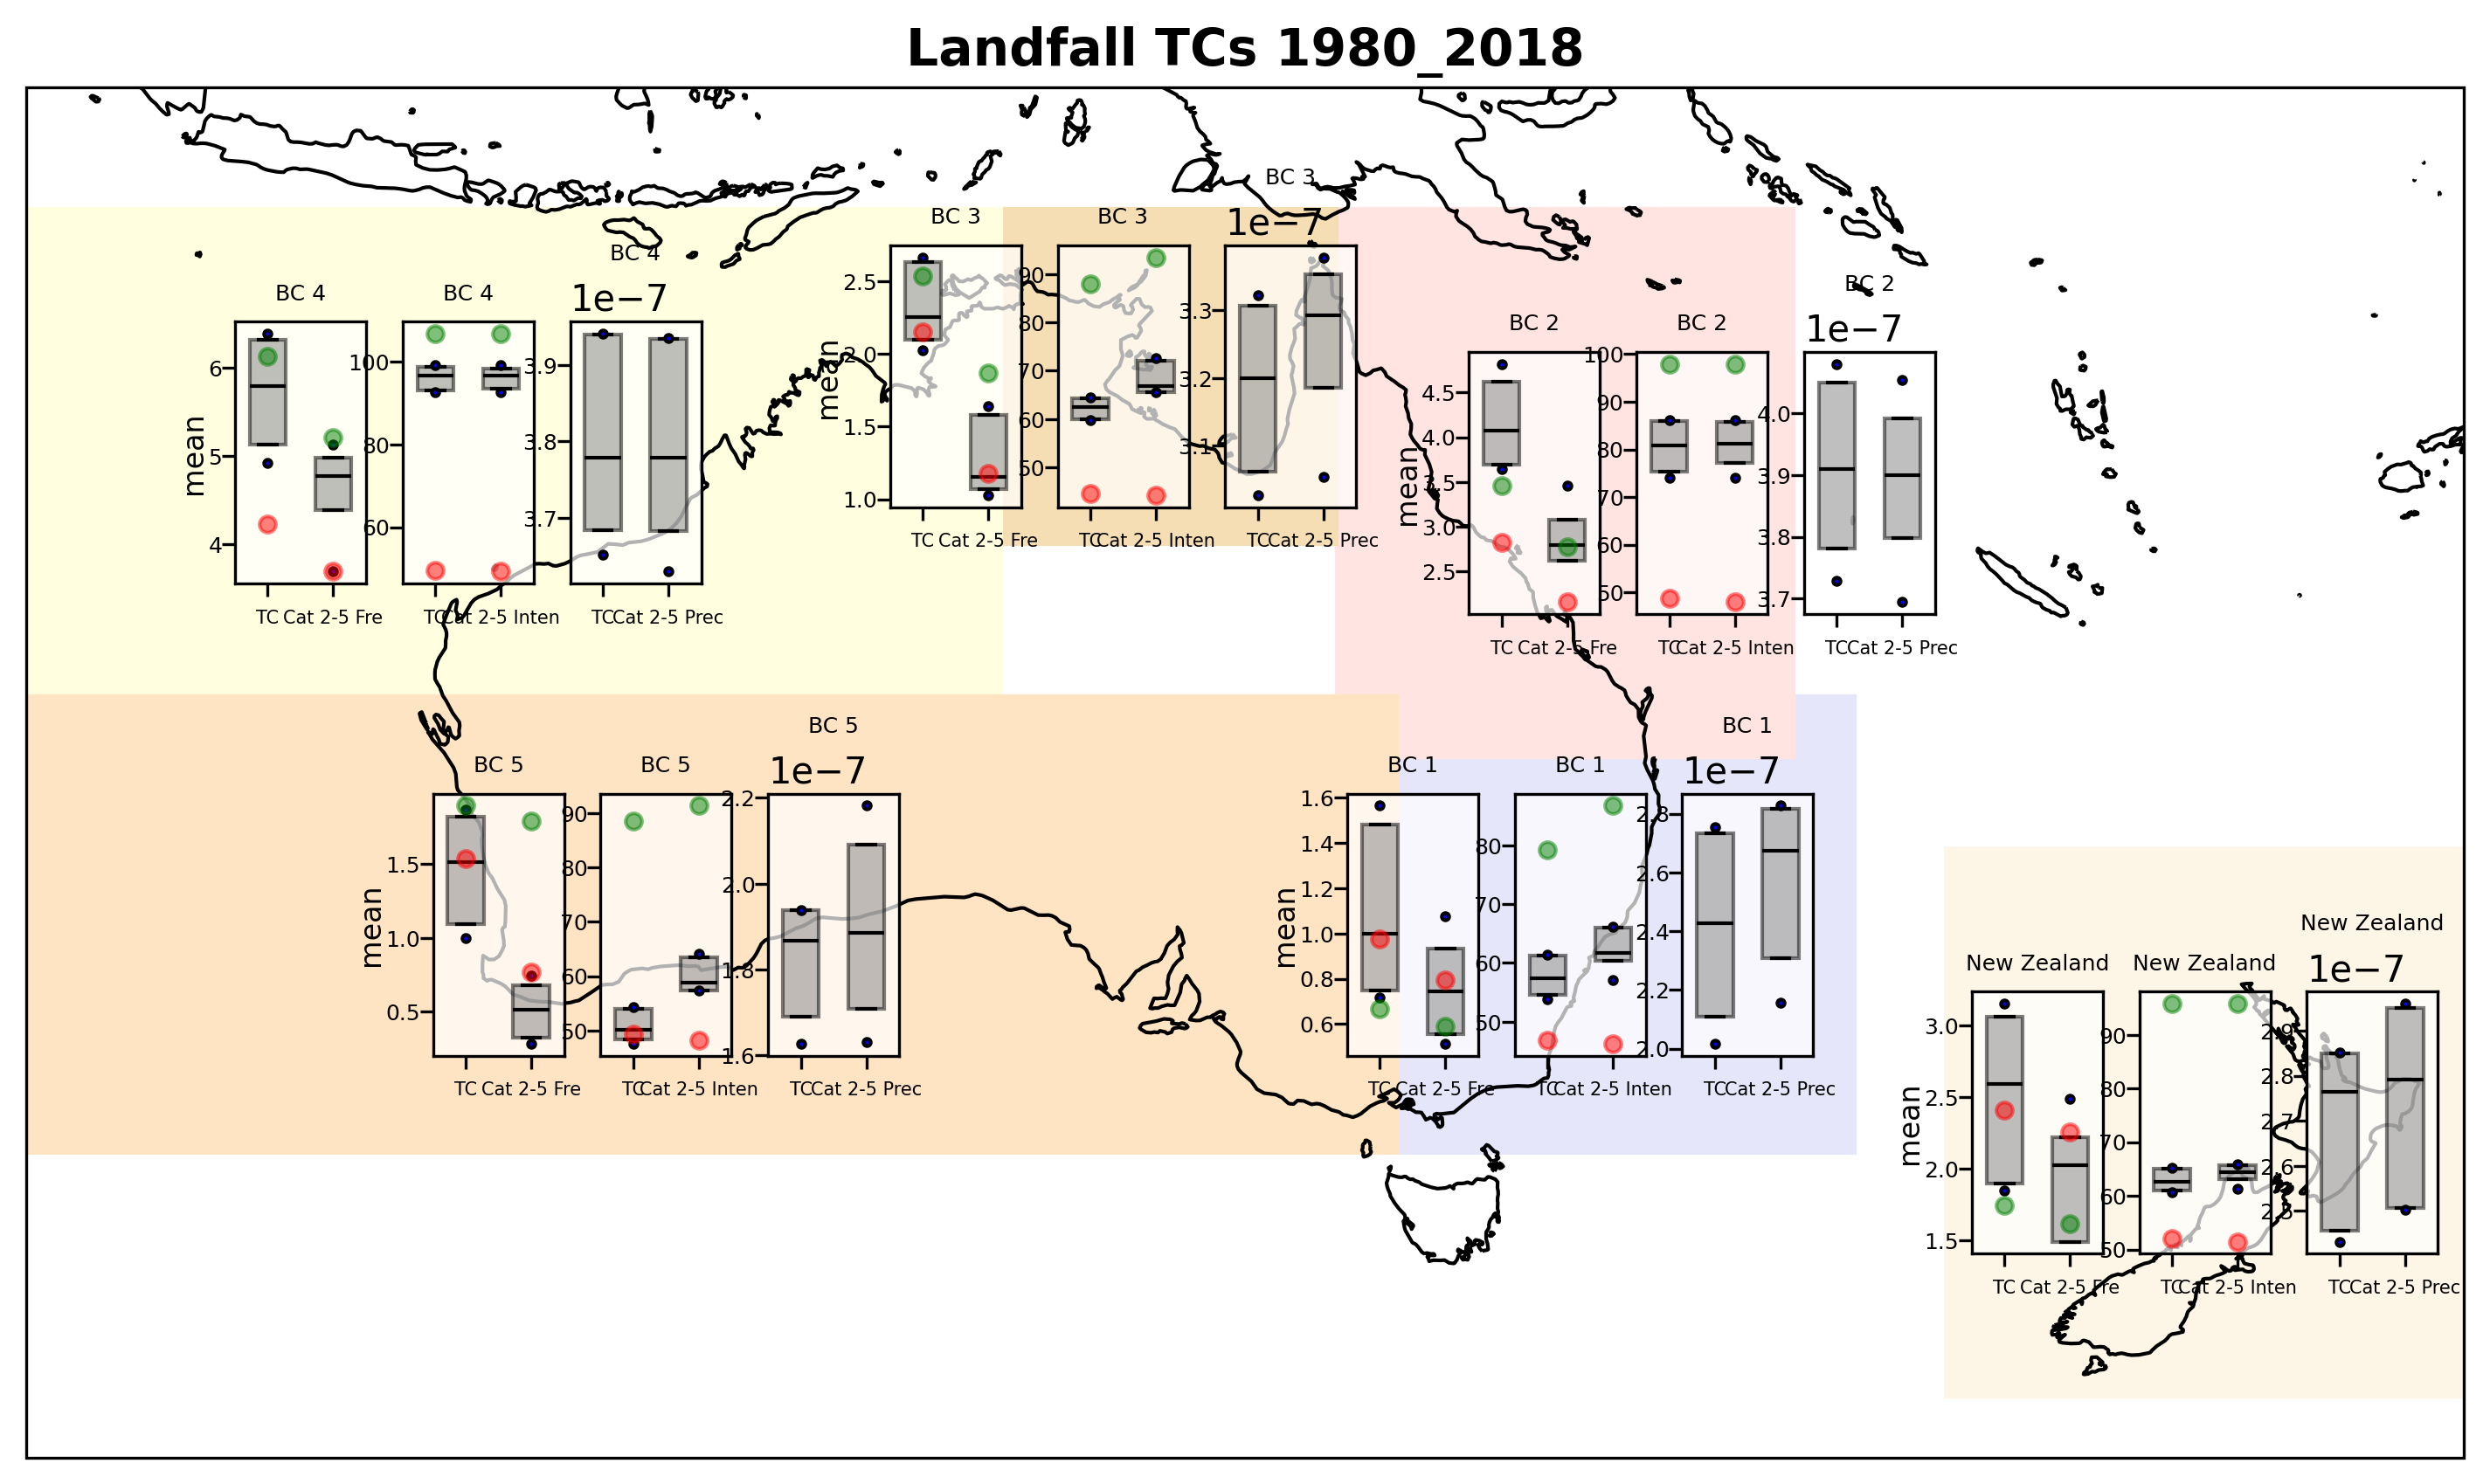

In [18]:
if landfall == True:
    call_box_custom_inset_3p(slope_4d_h, is_commonY = False, title_s='Landfall TCs 1980_2018', slope_ib=slope_ib_h, slope_e5=slope_e5_h)

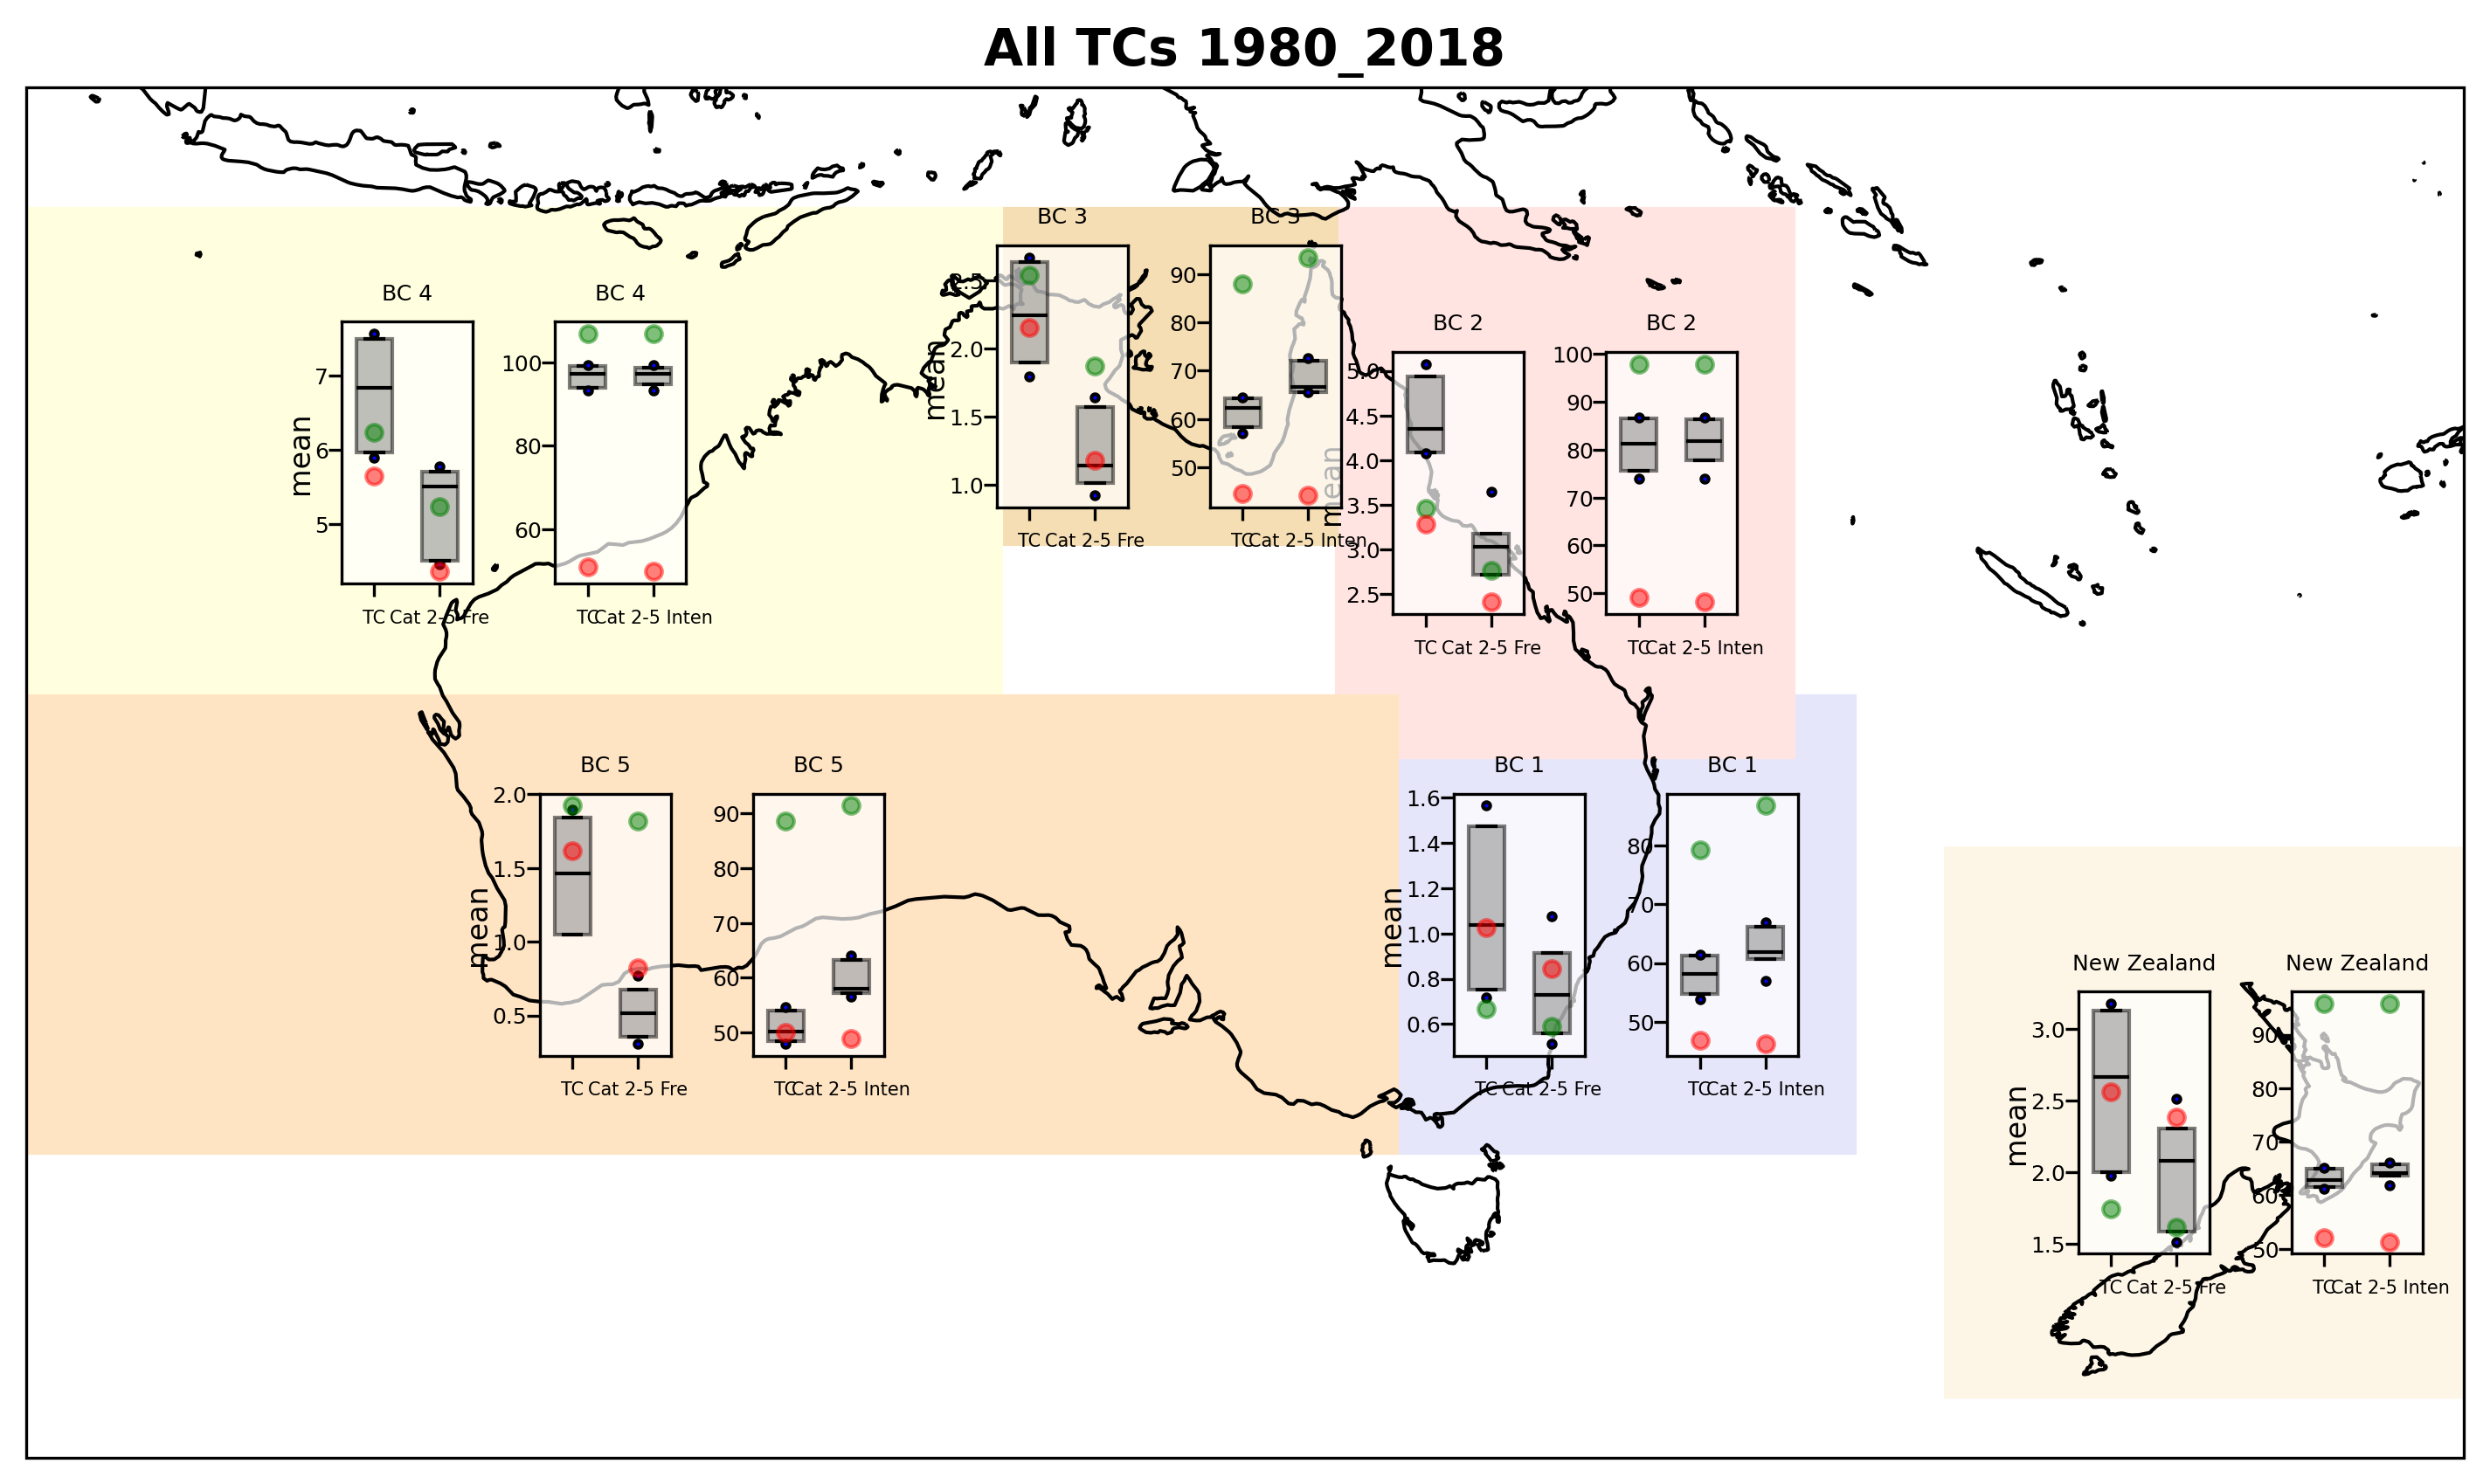

In [14]:
if landfall == True:
    #call_box_custom_inset_2p(slope_4d_h, is_commonY = False, title_s='Landfall TCs 1980_2018', slope_ib=slope_ib_h, slope_e5=slope_e5_h)
    call_box_custom_inset_3p(slope_4d_h, is_commonY = False, title_s='Landfall TCs 1980_2018', slope_ib=slope_ib_h, slope_e5=slope_e5_h)
else:
    call_box_custom_inset_2p(slope_4d_h, is_commonY = False, title_s='All TCs 1980_2018', slope_ib=slope_ib_h, slope_e5=slope_e5_h)

#### Future climate

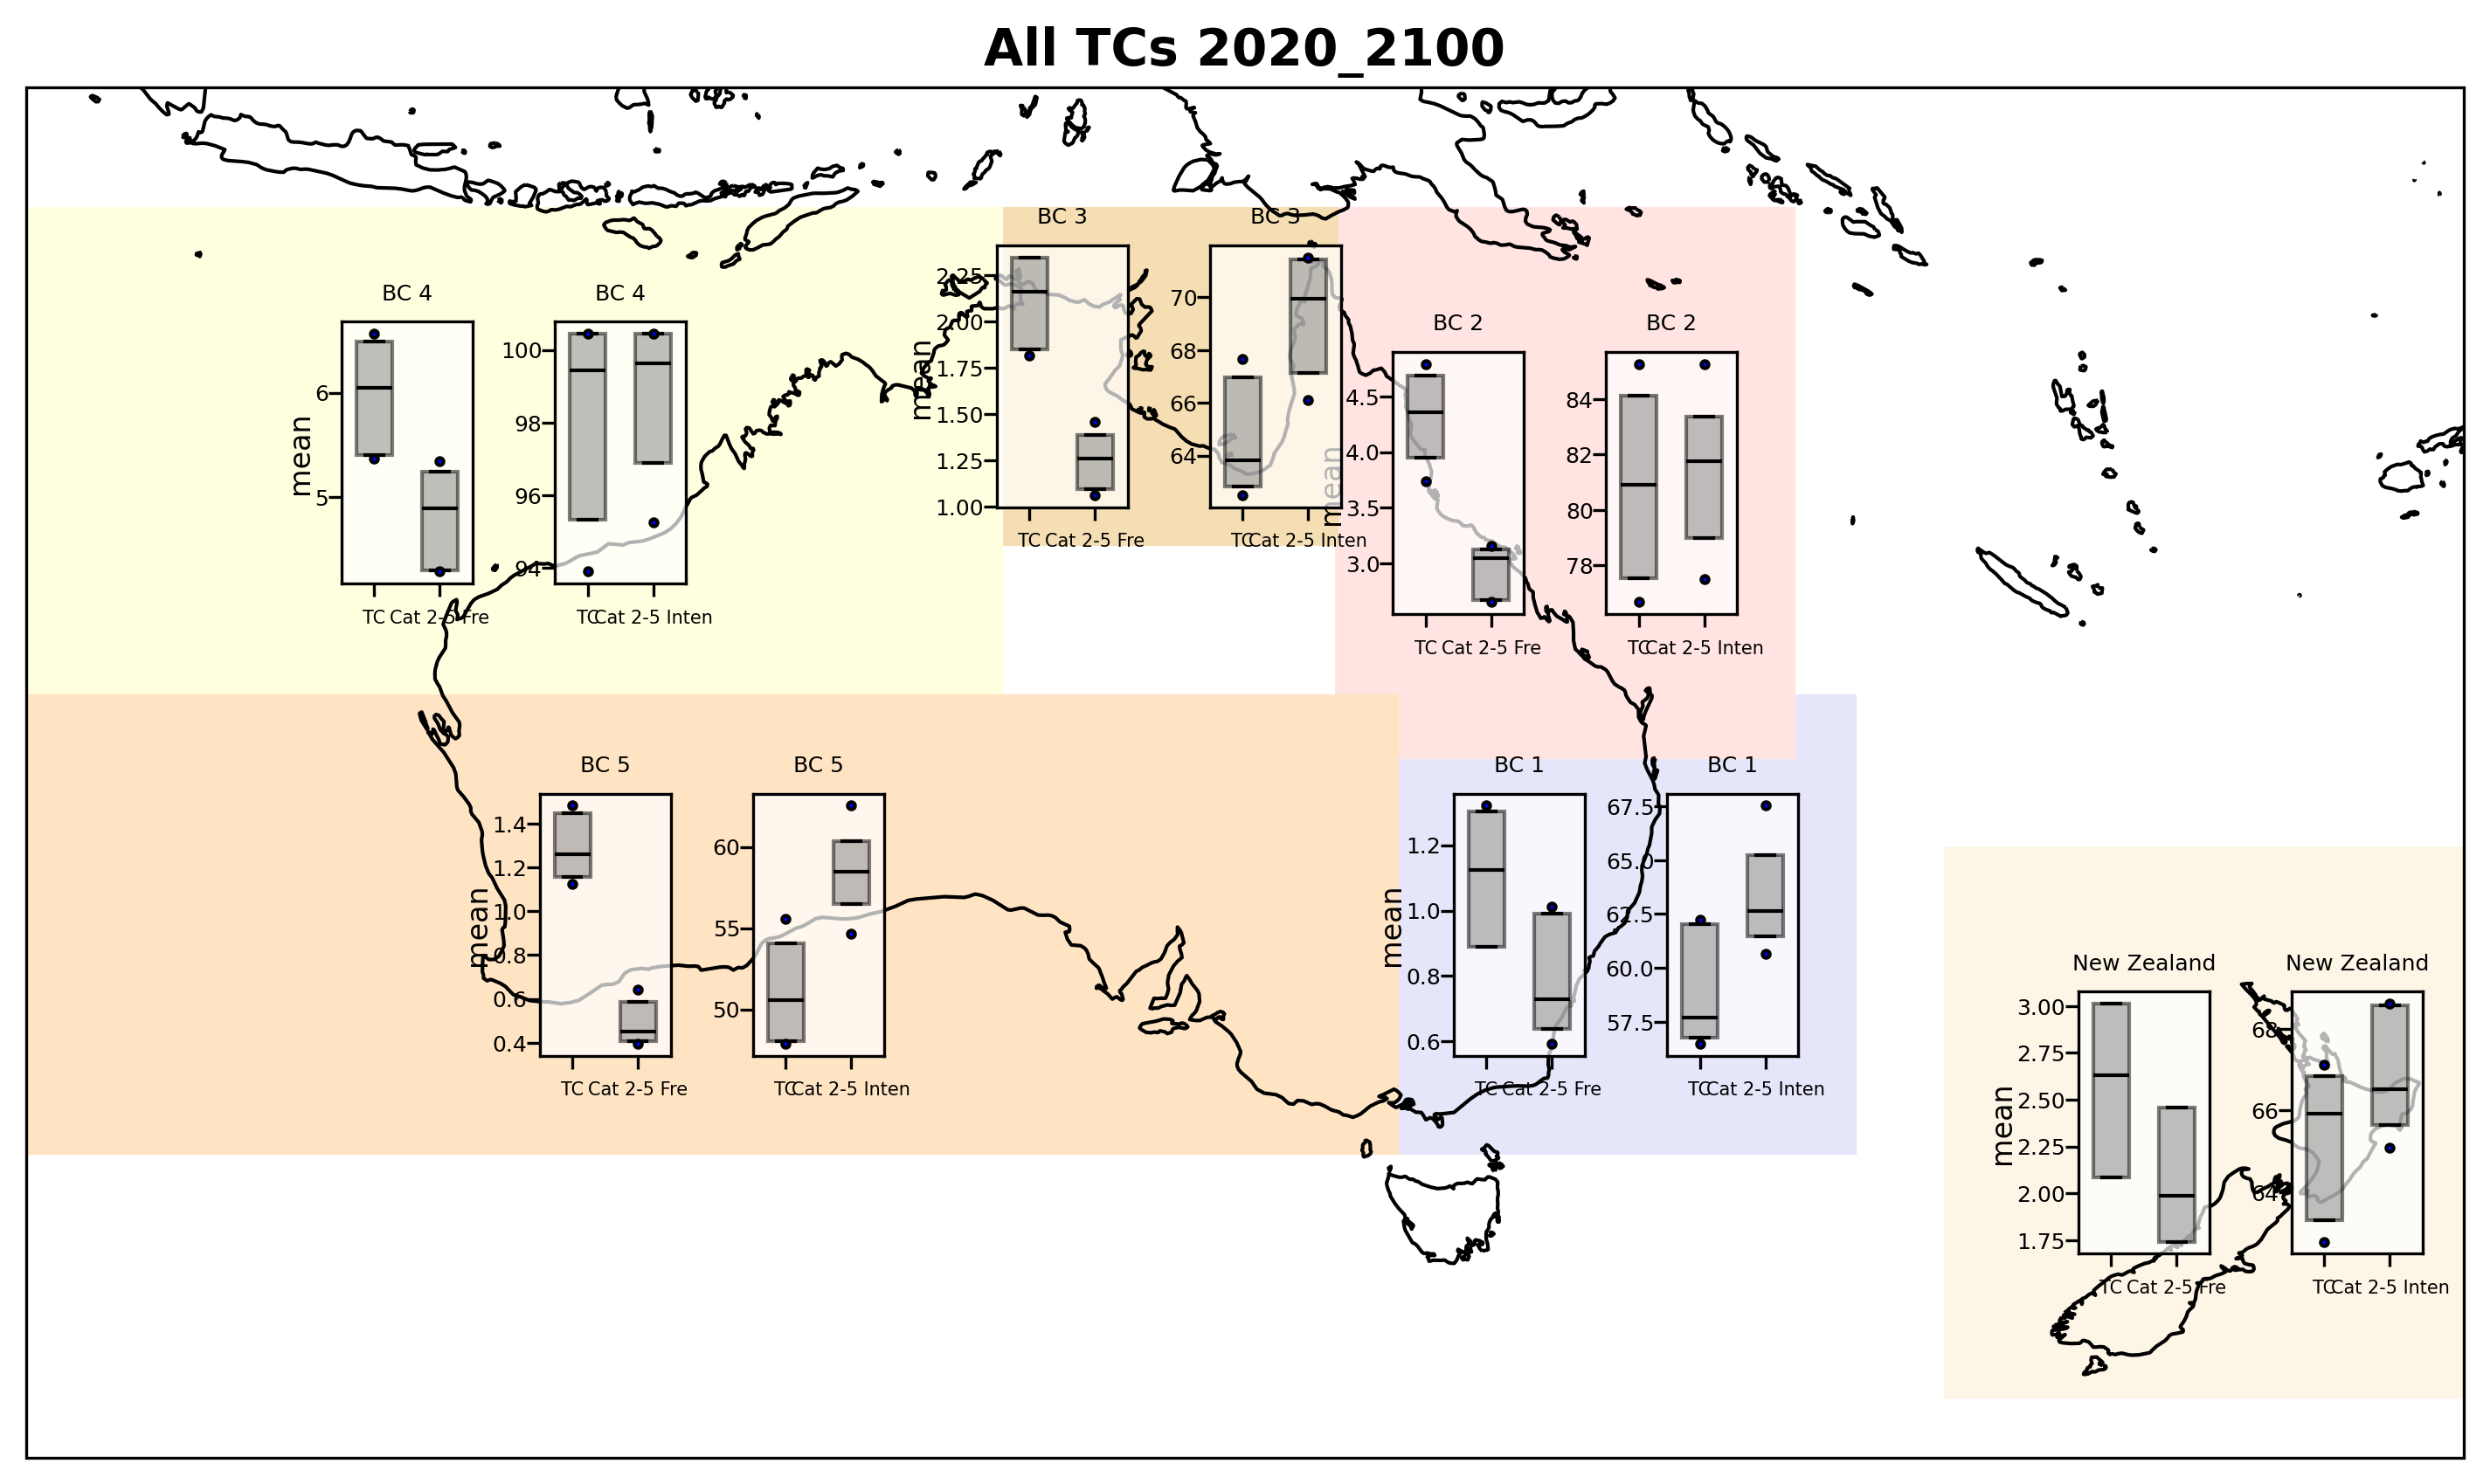

In [22]:
if landfall == True:
    call_box_custom_inset_2p(slope_4d_f, is_commonY = False, title_s='Landfall TCs 2020_2100', slope_ib=False, slope_e5=False)
else:
    call_box_custom_inset_2p(slope_4d_f, is_commonY = False, title_s='All TCs 2020_2100', slope_ib=False, slope_e5=False)
    

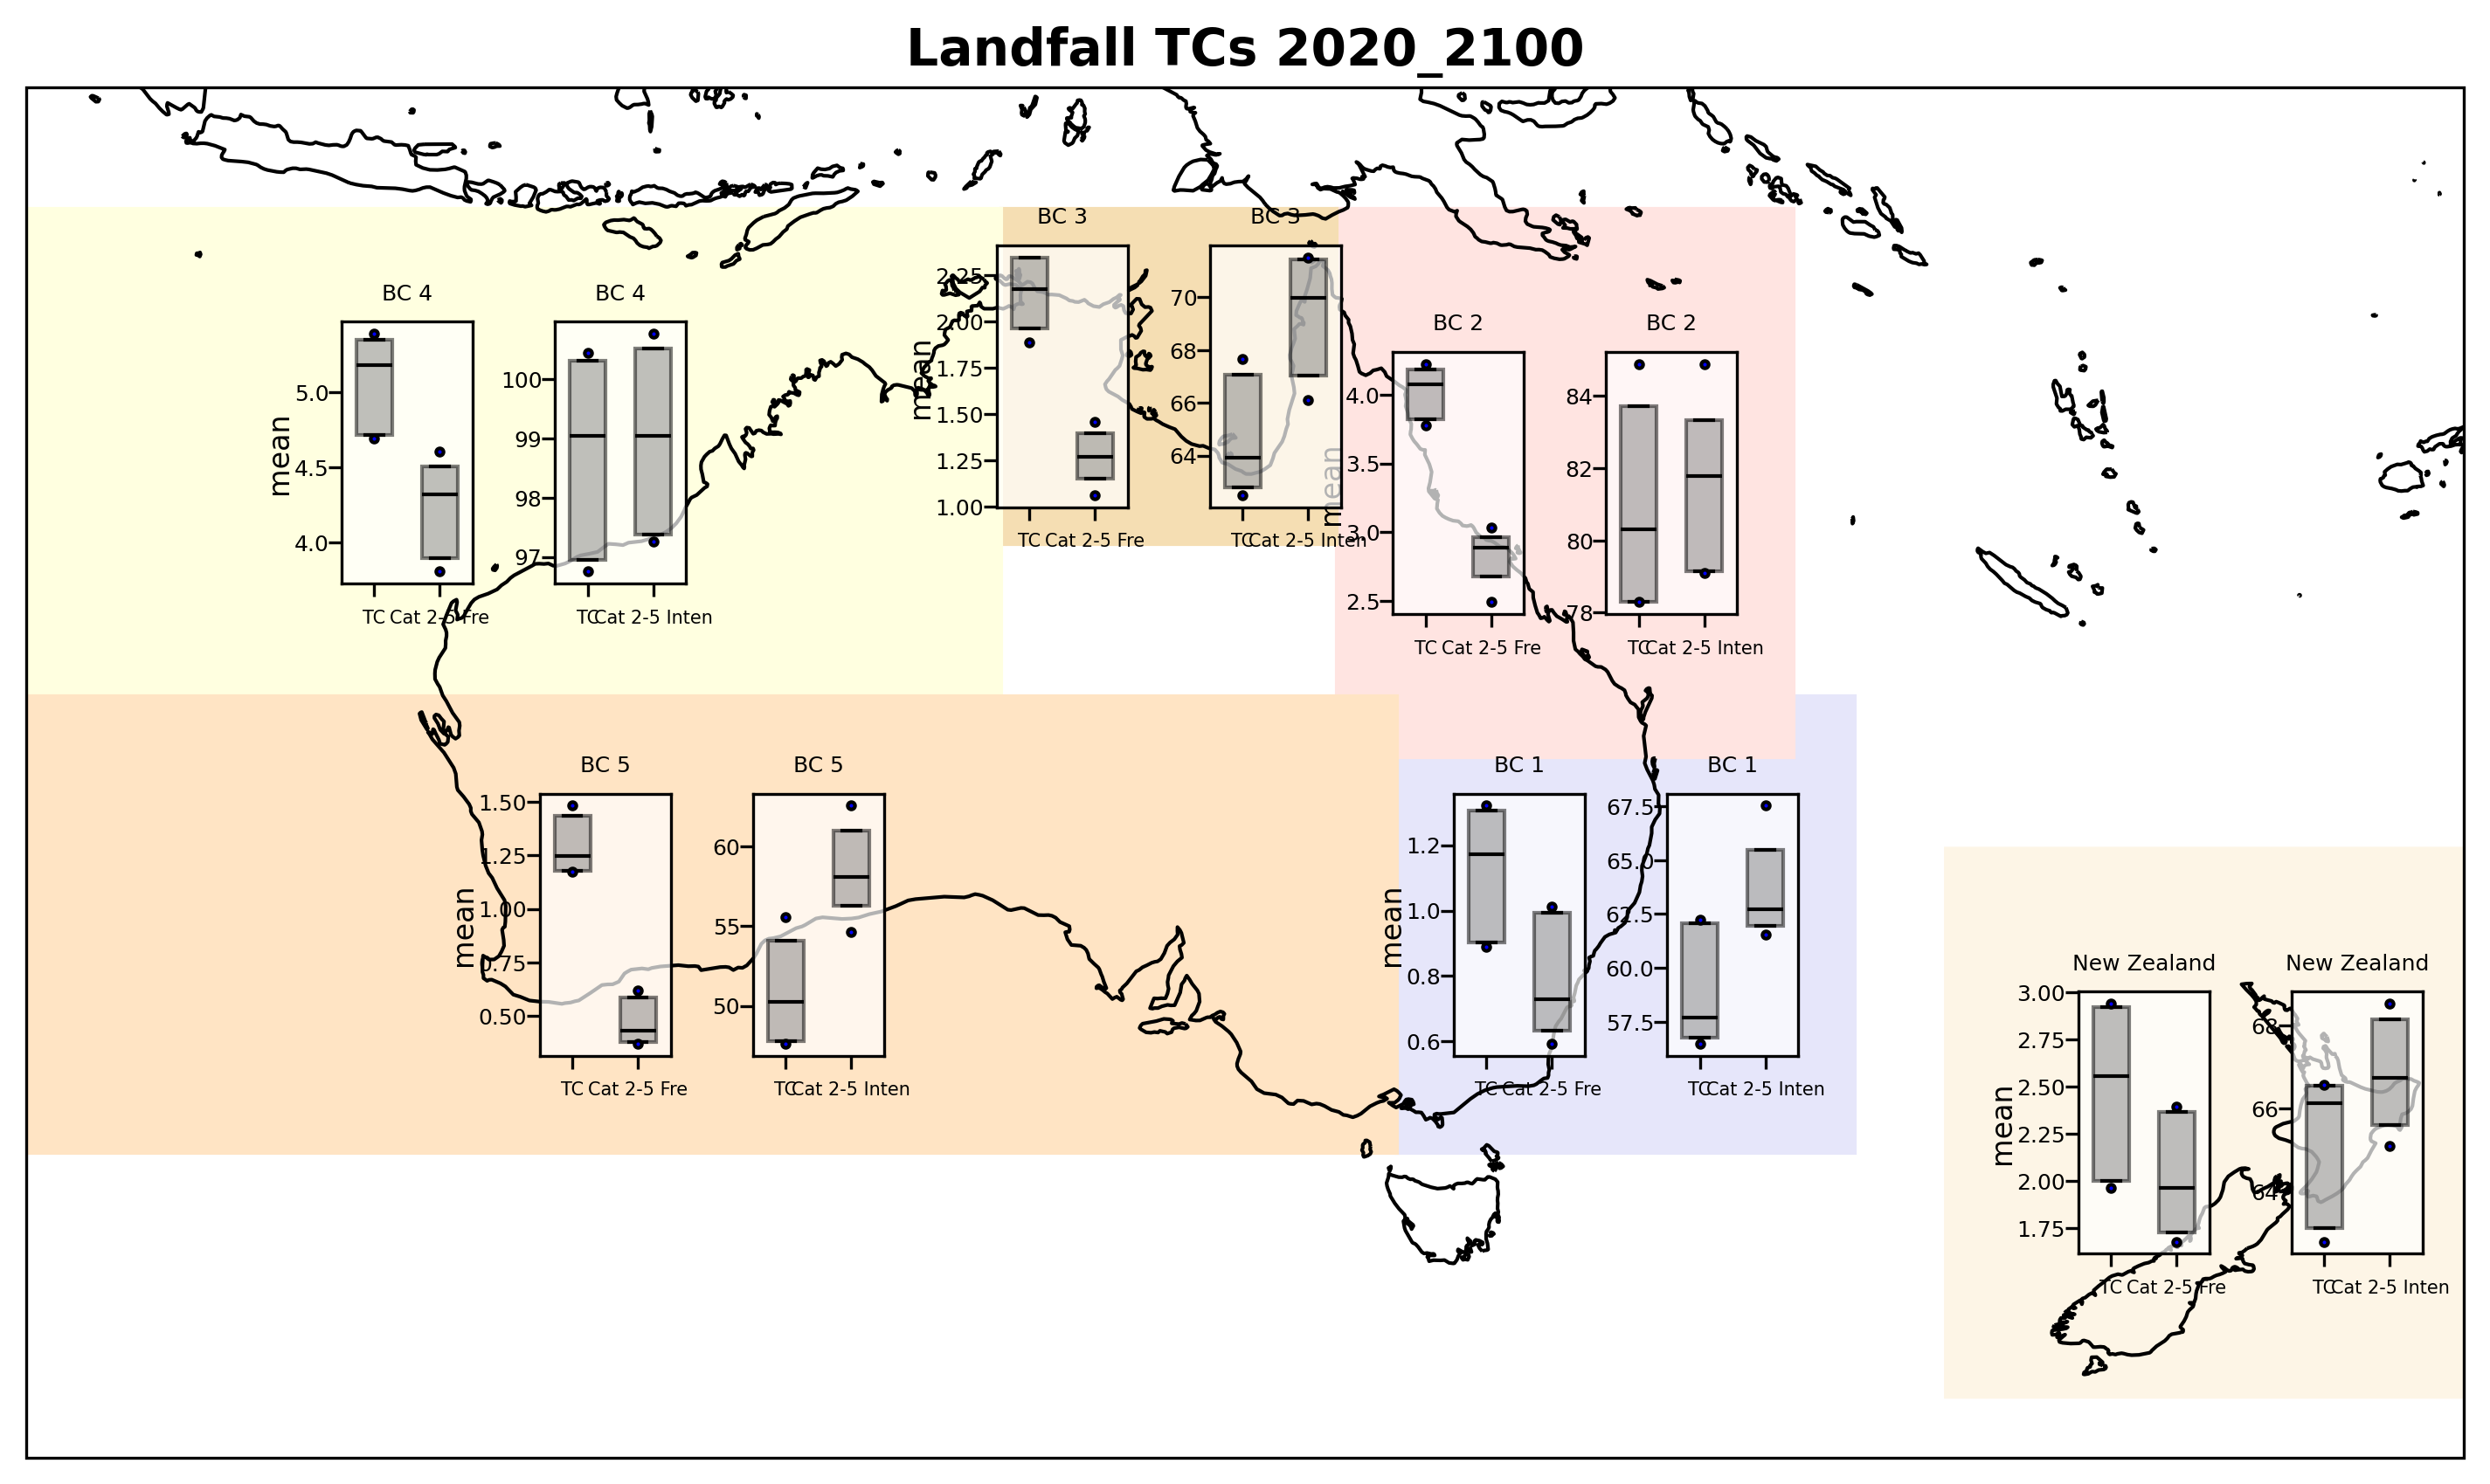

In [24]:
if landfall == True:
    call_box_custom_inset_2p(slope_4d_f, is_commonY = False, title_s='Landfall TCs 2020_2100', slope_ib=False, slope_e5=False)
else:
    call_box_custom_inset_2p(slope_4d_f, is_commonY = False, title_s='All TCs 2020_2100', slope_ib=False, slope_e5=False)